### Sports Ball Classification Using Support Vector Machines
This program classifies images of sports balls using a Support Vector Machine (SVM) model. It loads images from a dataset where each class of ball (e.g., football, basketball) is stored in labeled folders. The images are resized and flattened into 1D feature vectors, then split into training and testing sets. The SVM model is trained on these features to classify each ball type based on its pixel data.

In [6]:
import os
import cv2  # for image processing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import learning_curve


# Get the current notebook directory
notebook_dir = os.getcwd()
# Navigate to the "Project" folder)
project_dir = os.path.join(os.path.dirname(notebook_dir), 'Project')
# Construct paths to the dataset
dataset_dir = os.path.join(project_dir, 'archive (sport Balls)')
train_path = os.path.join(dataset_dir, 'train')
test_path = os.path.join(dataset_dir, 'test')
# Print the paths for verification
print(f"notebook_dir: {notebook_dir}")
print(f"Project_dir: {project_dir}")
print(f"Training path: {train_path}")
print(f"Testing path: {test_path}")

notebook_dir: C:\Users\badri\Introduction-to-AI-Group-14-\Notebooks
Project_dir: C:\Users\badri\Introduction-to-AI-Group-14-\Project
Training path: C:\Users\badri\Introduction-to-AI-Group-14-\Project\archive (sport Balls)\train
Testing path: C:\Users\badri\Introduction-to-AI-Group-14-\Project\archive (sport Balls)\test


In [8]:
image_size = (64, 64)  # Resize images for consistency

# preparing the dataset by loading the images and their labels from the dataset folder structure.
def load_images_from_folder(folder_path):
    #Initialise empty lists
    images = []
    labels = []
    #Loop through folders
    for label in os.listdir(folder_path):
        #create the path to the current subfolder
        label_path = os.path.join(folder_path, label)
        #Check if it’s a folder
        if os.path.isdir(label_path):  # Skip non-directory files if any
            #Loop through each image in the subfolder
            for filename in os.listdir(label_path):                
                img_path = os.path.join(label_path, filename) #For each file in the subfolder
                image = cv2.imread(img_path) # loads the image into memory using OpenCV.
                #Store valid images
                if image is not None: #checks if the image was loaded successfully.
                    image = cv2.resize(image, image_size)  # Resize to (64, 64)
                    images.append(image)
                    labels.append(label)
                    
    return images, labels

# Load images
train_images, train_labels = load_images_from_folder(train_path)
test_images, test_labels = load_images_from_folder(test_path)

# Check shapes
print("Train image shapes:", {img.shape for img in train_images})
print("Test image shapes:", {img.shape for img in test_images})

Train image shapes: {(64, 64, 3)}
Test image shapes: {(64, 64, 3)}


In [5]:
# Convert images and labels to numpy arrays
train_images = np.array(train_images)
test_images = np.array(test_images)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# Flatten images
train_images = train_images.reshape(len(train_images), -1)
test_images = test_images.reshape(len(test_images), -1)

# Convert the text labels (ball types) to numerical format using LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Initialize and train the SVM classifier
svm_model = SVC(kernel='poly', C=1, degree=3, gamma='scale', coef0=1)  # poly resulted in better accuracy than linear and rbf
svm_model.fit(train_images, train_labels_encoded)


# Predict on test data
test_predictions = svm_model.predict(test_images)

# Decode the labels back to original form
test_predictions_labels = label_encoder.inverse_transform(test_predictions)

# Calculate accuracy
accuracy = accuracy_score(test_labels_encoded, test_predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print(classification_report(test_labels_encoded, test_predictions, target_names=label_encoder.classes_))

Accuracy: 45.68%
                   precision    recall  f1-score   support

american_football       0.46      0.41      0.43        96
         baseball       0.34      0.38      0.36       100
       basketball       0.41      0.37      0.39        86
    billiard_ball       0.42      0.49      0.46       162
     bowling_ball       0.39      0.46      0.42       111
     cricket_ball       0.49      0.45      0.47       146
         football       0.45      0.38      0.41       151
        golf_ball       0.41      0.50      0.45       138
      hockey_ball       0.37      0.40      0.38       133
      hockey_puck       0.46      0.47      0.46        98
       rugby_ball       0.56      0.55      0.56       124
      shuttlecock       0.53      0.49      0.51       108
table_tennis_ball       0.52      0.56      0.54       156
      tennis_ball       0.66      0.54      0.60       123
       volleyball       0.46      0.30      0.37       109

         accuracy                    

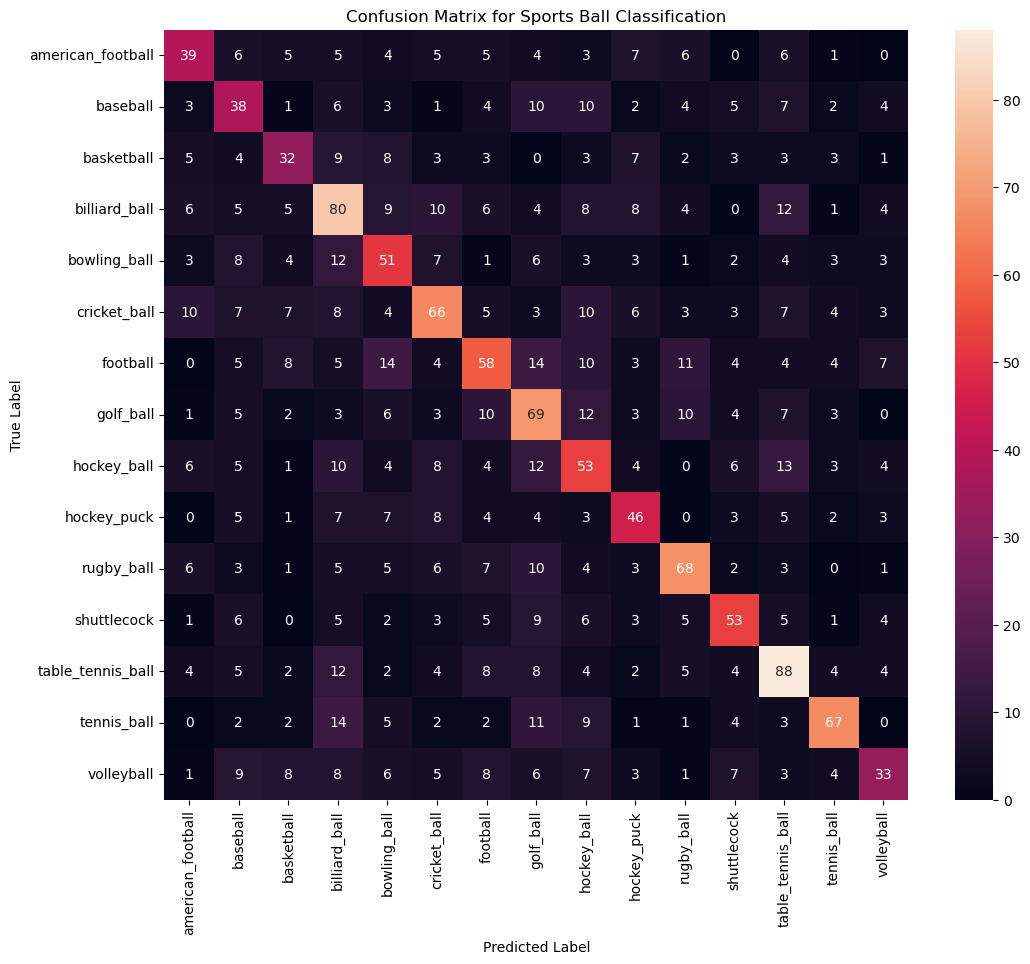

In [6]:
# Generate confusion matrix
conf_matrix = confusion_matrix(test_labels_encoded, test_predictions)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Sports Ball Classification")
plt.show()

### Class Distribution in Training and Test Sets
The following plot shows how many images are present for each class (ball type) in the training and test sets.
It helps to check for class balance. If certain ball types are underrepresented, the model might struggle to learn to classify those types correctly, leading to poor performance or bias towards more frequent classes. Identifying this early allows to take steps like collecting more images or applying techniques to balance the dataset.

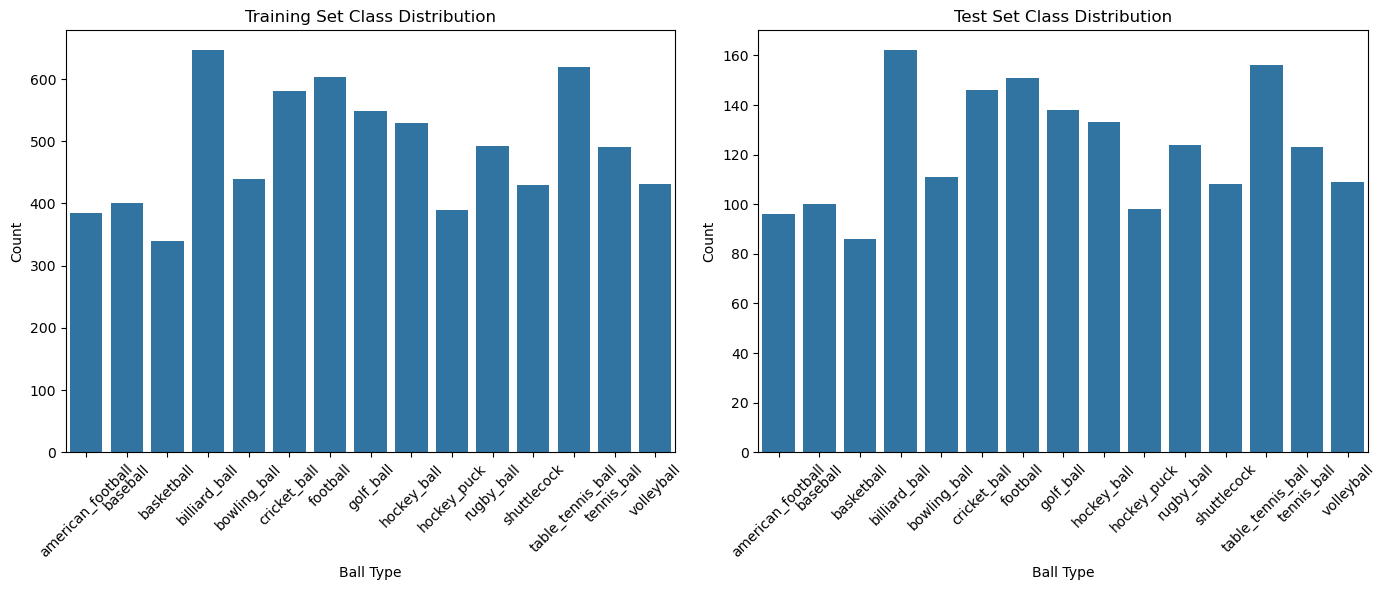

In [8]:
# Count the number of images per class in train and test sets
train_counts = np.unique(train_labels, return_counts=True)
test_counts = np.unique(test_labels, return_counts=True)

# Plot the distributions
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=train_counts[0], y=train_counts[1])
plt.title('Training Set Class Distribution')
plt.xlabel('Ball Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x=test_counts[0], y=test_counts[1])
plt.title('Test Set Class Distribution')
plt.xlabel('Ball Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Learning Curve
This plot shows the model’s accuracy on the training and validation sets as the size of the training set increases.
This helps to understand if the model is underfitting, overfitting, or has potential for improvement.

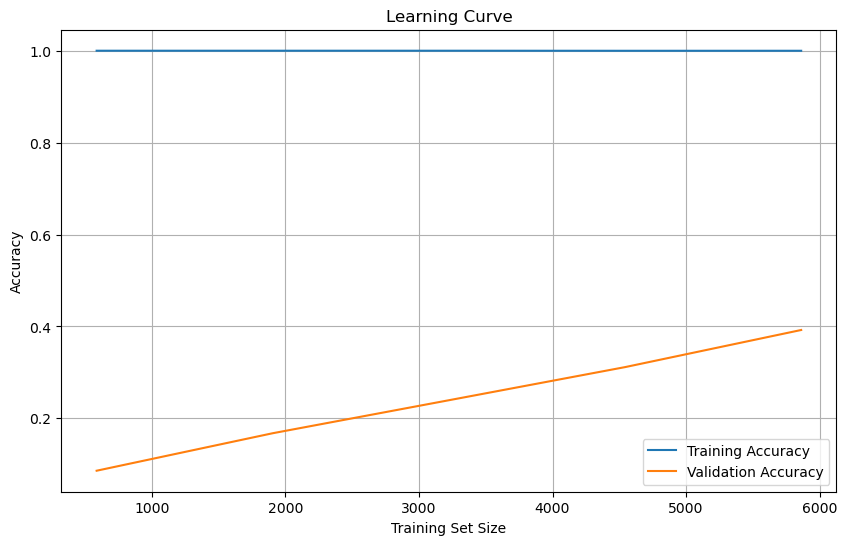

In [10]:
# Plot learning curve
train_sizes, train_scores, test_scores = learning_curve(SVC(kernel='linear'), train_images, train_labels_encoded, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy')
plt.plot(train_sizes, test_scores_mean, label='Validation Accuracy')
plt.title('Learning Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

###  Precision-Recall Curve (for each Class)
For each class, this curve shows the trade-off between precision (correct positive predictions among all positive predictions) and recall (correct positive predictions among all actual positives) at different decision thresholds.
This curve helps evaluate the model’s performance on each class, particularly for imbalanced datasets. High precision indicates fewer false positives, while high recall indicates fewer false negatives.

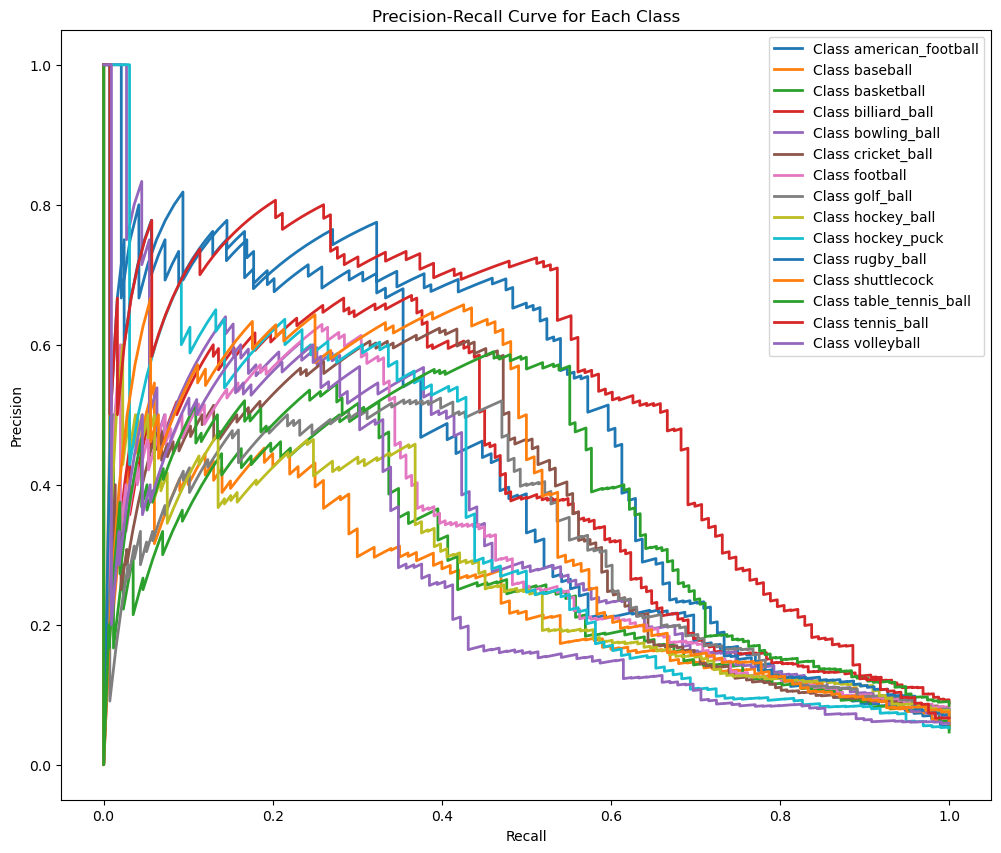

In [12]:
# Binarize labels for precision-recall curve plotting
y_test_bin = label_binarize(test_labels_encoded, classes=np.arange(len(np.unique(test_labels_encoded))))
y_scores = svm_model.decision_function(test_images)  # decision_function gives scores to plot precision-recall

plt.figure(figsize=(12, 10))
for i in range(len(np.unique(test_labels_encoded))):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {label_encoder.inverse_transform([i])[0]}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc='best')
plt.show()
